Training shape: (25000, 200)
Testing shape: (25000, 200)
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 227ms/step - accuracy: 0.6627 - loss: 0.5808 - val_accuracy: 0.8510 - val_loss: 0.3554
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 258ms/step - accuracy: 0.8997 - loss: 0.2592 - val_accuracy: 0.8738 - val_loss: 0.3030
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 184ms/step - accuracy: 0.9387 - loss: 0.1698 - val_accuracy: 0.8644 - val_loss: 0.3396
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 149ms/step - accuracy: 0.9477 - loss: 0.1415 - val_accuracy: 0.8754 - val_loss: 0.3593
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 139ms/step - accuracy: 0.9681 - loss: 0.0959 - val_accuracy: 0.8558 - val_loss: 0.3759
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8503 - loss: 0.3957

Test Accuracy: 0.8530
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step


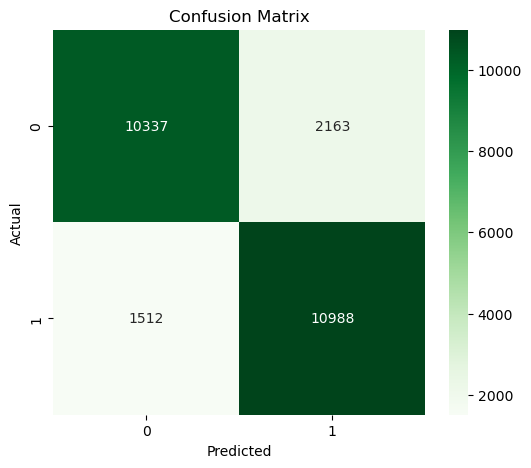


Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.83      0.85     12500
           1       0.84      0.88      0.86     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



In [4]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# -----------------------------
# a) DATA PREPARATION
# -----------------------------

# Load dataset (top 10,000 most frequent words)
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

# Pad sequences (make all reviews same length)
max_len = 200
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

# -----------------------------
# b) DEFINE LSTM MODEL & TRAIN
# -----------------------------

model = Sequential()

# Embedding Layer
model.add(Embedding(input_dim=vocab_size, output_dim=128))

# LSTM Layer
model.add(LSTM(64, return_sequences=False))

# Dropout (to prevent overfitting)
model.add(Dropout(0.5))

# Output Layer (Binary classification: Positive/Negative)
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train,
                    epochs=5,
                    batch_size=128,
                    validation_split=0.2)

# -----------------------------
# c) EVALUATION
# -----------------------------

# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {accuracy:.4f}")

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype("int32")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes))